## 1. 查看 Python 版本

`!python -V` 是 IPython 魔术命令,用来确认当前 Notebook 实际使用的解释器版本,
避免后续因版本差异出现 API 不兼容的问题。

In [1]:
!python -V

Python 3.10.20


## 2. 导入 NumPy 并创建单位矩阵

- `import numpy as np`:NumPy 的通用惯例是把别名写成 `np`。
- `np.eye(5)`:生成 5x5 的单位矩阵,主对角线为 1、其余为 0,常用于解线性方程。

In [2]:
import numpy as np  # 导入 NumPy 并绑定惯用别名 np
print(np.eye(5))  # eye(n) 生成 n x n 单位矩阵,主对角线为 1

[[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]


## 3. 用 np.array 把 Python 列表转成数组

- 一维列表 -> 一维数组;嵌套的二维列表 -> 二维数组。
- `np.array` 会为所有元素推断统一的数据类型,不会像原生 list 那样允许混合类型。

In [3]:
list_1 = [1,2,3,4]  # 一维 Python 列表
list_2 = [[1,2,3,4],[5,6,7,8]]  # 二维嵌套列表:外层 2 个元素,每个内层 4 个
arr_1 = np.array(list_1)  # 转为一维 int 数组,形状 (4,)
arr_2 = np.array(list_2)  # 转为二维 int 数组,形状 (2, 4)
print(f"一维数组为\n{arr_1}")  # f-string 中 \n 换行,{} 取变量值
print(f"二维数组为\n{arr_2}")

一维数组为
[1 2 3 4]
二维数组为
[[1 2 3 4]
 [5 6 7 8]]


## 4. np.arange:等差数列

签名 `np.arange(start, stop, step, dtype=None)`,按固定步长生成数组,
规则是**含 start 不含 stop**。本例得到 `[0 1 2 3 4 5]`,显式写 `dtype=int` 可避免
默认整型推断带来的歧义。

In [4]:
# numpy.arange(start,stop,step,dtype=None)
a = np.arange(0,6,1,dtype=int)  # 从 0 起步长 1 到 6 结束(含 0 不含 6),显式指定整型
print(a)

[0 1 2 3 4 5]


## 5. np.linspace:等距数列

签名 `np.linspace(start, stop, num=50, ...)`,把 `[start, stop]` 区间均分成 `num` 个点,
**默认包含 stop**,因此步长是 `(stop-start)/(num-1)`。
需要固定步长用 `arange`,需要固定点数用 `linspace`。

In [5]:
# linspace(start,stop,num=50,endpoint=True,retstep=False,dtype=None,axis=0)
np.linspace(0,1,10)  # 0~1 取 10 个等距点,含首尾,步长为 1/9

array([0.        , 0.11111111, 0.22222222, 0.33333333, 0.44444444,
       0.55555556, 0.66666667, 0.77777778, 0.88888889, 1.        ])

## 6. np.logspace:对数等距数列

签名 `np.logspace(start, stop, num, base=10)`,返回 `base ** x` 形式的数列,
其中 `x` 在 `[start, stop]` 上等距分布。`logspace(0, 1, 10)` 得到 1、1.33、1.78 … 10 的等比数列。

In [6]:
# numpy.logspace(start,stop,num,endpoint,base,dtype)
np.logspace(0,1,10)  # 10 的 0~1 等距次幂,即 1 到 10 的等比数列

array([ 1.        ,  1.29154967,  1.66810054,  2.15443469,  2.7825594 ,
        3.59381366,  4.64158883,  5.9948425 ,  7.74263683, 10.        ])

## 7. 特殊数组:zeros / ones / empty

- `np.zeros(5)`:长度为 5 的全 0 数组,常用于初始化累加器。
- `np.ones(5)`:全 1 数组,常作为乘法单位元。
- `np.empty(10)`:只申请内存不做初始化,元素是内存里的残留值,**不能当成 0 使用**。

In [7]:
# numpy.zeros(shape,dtype=float,order='C')
# numpy.ones(shape,dtype=None,order='C')
# numpy.empty(shape,dtype=float,order='C')
zero = np.zeros(5)  # 长度为 5 的全 0 浮点数组
one = np.ones(5)  # 长度为 5 的全 1 浮点数组
empty = np.empty(10)  # 长度 10,只占内存不做初始化,内容是残留值
print(f"元素个数为5的全0数组:\n{zero}")
print(f"元素个数为5的全1数组:\n{one}")
print(f"元素个数为10的空值数组:\n{empty}")

元素个数为5的全0数组:
[0. 0. 0. 0. 0.]
元素个数为5的全1数组:
[1. 1. 1. 1. 1.]
元素个数为10的空值数组:
[ 1.          1.29154967  1.66810054  2.15443469  2.7825594   3.59381366
  4.64158883  5.9948425   7.74263683 10.        ]


## 8. 随机数:seed 与 randint

- `np.random.seed(0)`:固定随机种子,让每次运行结果都可复现,便于调试。
- `np.random.randint(1, 4, 5)`:左闭右开,从 `[1, 4)` 中取 5 个随机整数。

In [8]:
# random.randint()
np.random.seed(0)  # 固定随机种子,保证结果可复现
np.random.randint(1,4,5)  # 左闭右开,从 [1,4) 中取 5 个随机整数

array([1, 2, 1, 2, 2])

## 9. 数组与标量的算术运算

数组与单个数字运算时,该数字会被**广播**到每个元素,数组形状保持不变。
这是 NumPy 向量化运算最基础的形式。

In [9]:
arr = np.array([1,2,3,4,5])  # 一维 int 数组
print(f"Add:\n{arr+1}")  # 标量广播到每个元素 +1,形状不变
print(f"Sub:\n{arr-1}")  # 每个元素 -1
print(f"Mul:\n{arr*2}")  # 每个元素乘 2
print(f"Div:\n{arr/2}")  # 每个元素除以 2,结果为浮点

Add:
[2 3 4 5 6]
Sub:
[0 1 2 3 4]
Mul:
[ 2  4  6  8 10]
Div:
[0.5 1.  1.5 2.  2.5]


## 10. 数组与数组的算术运算

两个**形状相同**的数组按位置逐元素配对运算,结果形状不变。
形状不同时 NumPy 会尝试广播,不符合广播规则会抛 `ValueError`。

In [10]:
arr = np.array([1,2,3,4,5])  # 第一个一维数组
arr_1 = np.array([6,7,8,9,10])  # 第二个一维数组,长度与 arr 相同
print(f"arr+arr_1:\n{arr+arr_1}")  # 逐元素相加
print(f"arr-arr_1:\n{arr-arr_1}")  # 逐元素相减
print(f"arr*arr_1:\n{arr*arr_1}")  # 逐元素相乘,不是矩阵乘法
print(f"arr/arr_1:\n{arr/arr_1}")  # 逐元素相除

arr+arr_1:
[ 7  9 11 13 15]
arr-arr_1:
[-5 -5 -5 -5 -5]
arr*arr_1:
[ 6 14 24 36 50]
arr/arr_1:
[0.16666667 0.28571429 0.375      0.44444444 0.5       ]


## 11. 数组的比较运算

数组与标量或数组比较,返回的是**布尔数组**,可用于后续索引筛选。
单个布尔数组的元素结果需要用 `np.all` / `np.any` 汇总。

In [11]:
arr = np.array([1,2,3,4,5])  # 第一个一维数组
arr_1 = np.array([6,7,8,9,10])  # 第二个一维数组
print(f"arr<arr_1:{arr<arr_1}")  # 逐位置比较,返回布尔数组
print(f"arr>arr_1:{arr>arr_1}")
print(f"arr>=arr_1:{arr>=arr_1}")
print(f"arr<=arr_1:{arr<=arr_1}")
print(f"arr==arr_1:{arr==arr_1}")  # 相等比较同样返回布尔数组
print(f"arr!=arr_1:{arr!=arr_1}")

arr<arr_1:[ True  True  True  True  True]
arr>arr_1:[False False False False False]
arr>=arr_1:[False False False False False]
arr<=arr_1:[ True  True  True  True  True]
arr==arr_1:[False False False False False]
arr!=arr_1:[ True  True  True  True  True]


## 12. np.any 与 np.all

- `np.any(x)`:只要存在一个元素为真就返回 `True`(或运算)。
- `np.all(x)`:必须所有元素都为真才返回 `True`(与运算)。

In [12]:
new_arr = np.array([1,2,3,4,5,6])
print(np.any(new_arr))  # 任一元素为真即为 True,相当于逻辑或
print(np.all(new_arr))  # 全部元素为真才为 True,相当于逻辑与

True
True


## 13. 布尔数组的逻辑运算

`&` 是逻辑与、`|` 是逻辑或,作用在布尔数组上得到新的布尔掩码,
这是 `arr[mask]` 条件筛选的基础。注意不要写成 `and` / `or`。

In [13]:
new_arr = np.array([1,2,3,4,5,6])
new_arr1 = np.array([0,2,0,4,1,6])
result = (new_arr == 2) & (new_arr1 == 2)  # 逻辑与:两个数组都为 2 的位置
result1 = (new_arr == 2) | (new_arr1 == 2)  # 逻辑或:任一数组为 2 的位置
print(result)
print(result1)

[False  True False False False False]
[False  True False False False False]


## 14. 数组的幂运算

`**` 是幂运算符,`arr ** arr1` 表示逐元素求幂,结果形状与操作数相同。
本例得到 `1**0, 2**2, 3**5`。

In [14]:
new_arr = np.array([1,2,3])
new_arr1 = np.array([0,2,5])
print(new_arr**new_arr1)  # 逐元素幂运算:1**0, 2**2, 3**5

[  1   4 243]


## 15. 数组索引与切片

- `arr[1]`:按下标取单个元素。
- `arr2[1, 2]`:二维数组按行、列取值。
- `arr[0:3]` / `arr[1:]` / `arr[:3]`:左闭右开切片,索引可省略。
- `arr[0:5:2]`:带步长;`arr[-1::-2]`:负步长,从末尾反向每隔一个取值。

In [19]:
new_arr1 = np.array([0,2,5])
print(new_arr1[1])  # 单元素索引:取下标 1

new_arr2 = np.array([[0,2,5],[4,6,7]])
print(new_arr2[1,2])  # 二维索引:第 1 行第 2 列

new_arr3 = np.array([0,2,0,4,1,6])
print(new_arr3[0:3])  # 切片 [0,3),左闭右开取下标 0~2
print(new_arr3[1:])  # 从下标 1 取到末尾
print(new_arr3[:3])  # 取开头到下标 2,不含 3
print(new_arr3[0:5:2])  # 带步长 2:下标 0、2、4
print(new_arr3[-1::-2])  # 负步长:从末尾反向每隔一个取值

2
7
[0 2 0]
[2 0 4 1 6]
[0 2 0]
[0 0 1]
[6 4 2]


## 16. from numpy import * 与二维数组索引

`import *` 之后可直接写 `array` 而省略 `np.` 前缀(仅建议在教学/交互环境使用,
工程代码应始终显式写 `np.`)。

- `array([...])` 把三个 `arange` 拼成 3x7 的二维数组。
- `arr[2]` 取第 2 行;`arr[2, 3]` 取第 2 行第 3 列。
- `arr[:2, :3]` 行列都切片;`arr[:, :3]` 中的 `:` 表示该维度全取,只对列切片。

In [29]:
from numpy import *  # 导入全部名字,之后可省略 np. 前缀
arr = array([arange(1,8),arange(4,11),arange(8,15)])  # 3 行 7 列,每行是长度 7 的等差数列
print(arr)
print(arr[2])  # 取第 2 行,结果是一维数组
print(arr[2,3])  # 取第 2 行第 3 列的标量
print(arr[:2,:3])  # 行列都切片:前 2 行的前 3 列
print(arr[:,:3])  # 冒号表示该维度全取,只对列做切片

[[ 1  2  3  4  5  6  7]
 [ 4  5  6  7  8  9 10]
 [ 8  9 10 11 12 13 14]]
[ 8  9 10 11 12 13 14]
11
[[1 2 3]
 [4 5 6]]
[[ 1  2  3]
 [ 4  5  6]
 [ 8  9 10]]


## 17. reshape 变形与花式索引

- `reshape((5, 5))`:不改变元素顺序,把 25 个元素重排成 5x5。
- `arr[[1, 3, 4]]`:传入**列表**表示同时取多行(花式索引),返回的是副本。
- `arr[[1, 3, 4], [2, 3, 4]]`:行列都按列表取值,得到 3x3 子矩阵。

In [35]:
arr = np.arange(25).reshape((5,5))  # 0~24 按行重排成 5 x 5,元素顺序不变
print(arr)
print()
print(arr[[1,3,4]])  # 花式索引:用列表同时取第 1、3、4 行,返回副本
print()
print(arr[[1,3,4],[2,3,4]])  # 行列都按列表取值,得到 3 x 3 子矩阵

[[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]
 [15 16 17 18 19]
 [20 21 22 23 24]]

[[ 5  6  7  8  9]
 [15 16 17 18 19]
 [20 21 22 23 24]]

[ 7 18 24]


## 18. 布尔索引(掩码筛选)

用与数据等长的布尔数组做索引,`arr[boolarr]` 会**只保留**布尔值为 `True` 的位置,
返回的是一维结果。

本单元最后两行处于注释状态,取消注释即可看到筛选结果。

In [40]:
arr = np.arange(8)  # 生成 0~7 共 8 个元素
# arr
boolarr = np.array([True,False,False,True,True,True,False,True])  # 与 arr 等长的布尔掩码
# print(arr[boolarr])  # 取消注释可查看:只保留掩码为 True 的元素
# arr[boolarr]  # 取消注释可查看筛选结果

## 19. reshape 指定多个维度

元素总数不变的前提下可自由组合形状:12 个元素既能变成 4x3,
也能变成 2x3x2 的三维数组,`-1` 表示该维度由其余维度自动推断。

In [2]:
import numpy as np
arr = np.array([1,2,3,4,5,6,7,8,9,10,11,12])
newarr = arr.reshape(4,3)  # 12 个元素重排为 4 行 3 列
newarr1 = arr.reshape(2,3,2)  # 同样 12 个元素重排为 2 x 3 x 2 三维
print(newarr)
# print()
print(newarr1)

[[ 1  2  3]
 [ 4  5  6]
 [ 7  8  9]
 [10 11 12]]
[[[ 1  2]
  [ 3  4]
  [ 5  6]]

 [[ 7  8]
  [ 9 10]
  [11 12]]]


## 20. 遍历数组

数组可直接迭代:

- **一维数组**:每次迭代得到一个标量。
- **二维数组**:每次迭代得到一行(一维数组)。

In [48]:
arr = np.array([1,2,3])
for x in arr:  # 一维数组:每次迭代得到一个标量
    print(x)  # 逐个打印元素

arr1 = np.array([[1,2,3],[4,5,6]])
for x in arr1:  # 二维数组:每次迭代得到一行数组
    print(x)

1
2
3
[1 2 3]
[4 5 6]


## 21. np.mat 用字符串创建矩阵

`np.mat` 直接接受 MATLAB 风格字符串,行用 `;` 分隔、列用空格分隔。

注意:`np.mat` 是历史遗留 API,新代码请优先使用 `np.array`。

In [50]:
arr = np.mat('1 2 5 6; 3 4 7 8')  # 字符串构造矩阵:分号分行,空格分列
arr  # 单独一行写变量名即可显示其值

matrix([[1, 2, 5, 6],
        [3, 4, 7, 8]])

## 22. np.mat 与 np.zeros 组合

先由 `np.zeros` 生成 5x5 浮点数组,再交给 `np.mat` 转成矩阵类型,
这是构造指定形状零矩阵的常见写法。

In [3]:
arr = np.mat(np.zeros((5,5)))  # 先造 5 x 5 全 0 数组,再转成矩阵
arr  # 显示矩阵内容

matrix([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]])

## 23. 用已有数组再包一层

`np.array(...)` 的参数本身是数组时,会返回等价的新数组,
此处由 `np.ones((5, 5))` 构造出 5x5 全 1 数组。

In [4]:
arr = np.array(np.ones((5,5)))  # 生成 5 x 5 全 1 数组并用 np.array 封装
arr  # 显示结果

array([[1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.]])

## 24. 随机矩阵

`np.random.randint(1, 6, size=(5, 5))` 生成 5x5、取值范围 `[1, 6)` 的随机整数矩阵。

In [5]:
arr = np.mat(np.random.randint(1,6,size=(5,5)))  # 5 x 5 随机整数矩阵,取值范围 [1, 6)
arr  # 显示随机矩阵

matrix([[2, 5, 3, 3, 5],
        [4, 3, 4, 2, 4],
        [5, 2, 1, 1, 4],
        [2, 5, 1, 1, 3],
        [1, 5, 2, 1, 3]])

## 25. np.diag 构造对角矩阵

把一维数组交给 `np.diag`,会把它摆到主对角线上、其余位置补 0;
若传入二维数组则返回其对角线元素。

In [6]:
arr = np.mat(np.diag([1,2,3,4,5]))  # 把一维数组摆到主对角线,其余补 0
arr  # 显示对角矩阵

matrix([[1, 0, 0, 0, 0],
        [0, 2, 0, 0, 0],
        [0, 0, 3, 0, 0],
        [0, 0, 0, 4, 0],
        [0, 0, 0, 0, 5]])

## 26. 矩阵运算:+ - / 与 *

- 矩阵的 `*` 是**矩阵乘法**(行 x 列),不是逐元素乘法。
- 除法 `/` 是逐元素除法。
- `arr_1 * arr_2`(都是 2x4)被注释掉了:矩阵乘法要求左矩阵的列数等于右矩阵的行数,
  2x4 与 2x4 不满足,会抛 `ValueError`。
- `arr_3 * arr_2` 是 (4,2) x (2,4),内维度 2 == 2 匹配,结果为 4x4,合法。

In [12]:
arr_1 = np.mat([[1,2,5,6],[3,4,7,8]])
arr_2 = np.mat([[1,2,5,6],[3,4,7,8]])
print(arr_1+arr_2,'\n')  # 矩阵相加,逐元素
print(arr_1-arr_2,'\n')  # 矩阵相减,逐元素
# print(arr_1*arr_2,'\n')# ValueError  # 矩阵乘法要求内维度匹配:2x4 与 2x4 不满足,会报错
print(arr_1/arr_2)  # 逐元素相除,不是矩阵求逆
print('='*20)  # 打印分隔线,便于区分不同结果
arr_3 = np.mat([[1,2],[3,4],[3,4],[3,4]])  # 4 x 2 矩阵,作为矩阵乘法的左操作数
print(arr_3 * arr_2)  # (4,2) x (2,4),内维度 2 匹配,结果是 4 x 4

[[ 2  4 10 12]
 [ 6  8 14 16]] 

[[0 0 0 0]
 [0 0 0 0]] 

[[1. 1. 1. 1.]
 [1. 1. 1. 1.]]
[[ 7 10 19 22]
 [15 22 43 50]
 [15 22 43 50]
 [15 22 43 50]]


## 27. 矩阵转置 .T

`.T` 把行与列互换,4x2 转置后变为 2x4。

In [13]:
mat = np.mat([[1,2],[3,4],[7,8],[5,6]])
print(f"转置前为:\n{mat}")
print(f"转置后为:\n{mat.T}")  # .T 取转置,形状由 4x2 变为 2x4

转置前为:
[[1 2]
 [3 4]
 [7 8]
 [5 6]]
转置后为:
[[1 3 7 5]
 [2 4 8 6]]


## 28. 矩阵求逆 .I

`.I` 返回矩阵的逆矩阵(等价于 `np.linalg.inv`),要求矩阵是**方阵**且行列式不为 0,
否则结果会全是 inf/nan 或直接报错。

In [14]:
mat = np.mat([[1,2],[3,4],[7,8],[5,6]])
print(f"求逆前为:\n{mat}")
print(f"求逆后为:\n{mat.I}")  # .I 求逆矩阵,要求方阵且行列式不为 0

求逆前为:
[[1 2]
 [3 4]
 [7 8]
 [5 6]]
求逆后为:
[[-1.00000000e+00 -5.00000000e-01  5.00000000e-01  1.60635394e-15]
 [ 8.50000000e-01  4.50000000e-01 -3.50000000e-01  5.00000000e-02]]


## 29. amin / amax:最值与 axis 参数

- `np.amin(a)` 不传 `axis` 时返回**整个数组**的最小值。
- `axis=1` 按行(每行一个最小值),`axis=0` 按列(每列一个最小值)。
- 数组方法 `a.min(axis=...)` 与之等价。

In [18]:
import numpy as np
a = np.array([[3,7,5],[8,4,3],[2,4,9]])  # 3 x 3 二维数组
print(a)
print(f"amin(a,1):{np.amin(a,1)}")  # axis=1 按行取最小值,每行一个
print(f"amin(a,0):{np.amin(a,0)}")  # axis=0 按列取最小值,每列一个
print(f"amax(a):{np.amax(a)}")  # 不传 axis,返回整个数组的最大值

[[3 7 5]
 [8 4 3]
 [2 4 9]]
amin(a,1):[3 3 2]
amin(a,0):[2 4 3]
amax(a):9


## 30. np.ptp:极差

`ptp` 是 peak-to-peak,即 `最大值 - 最小值`,反映数据的取值跨度。
不传 `axis` 得到全局极差,传 `axis` 则按行/列分别计算。

注意:`ndarray.ptp()` 方法在 NumPy 2.0 中已移除,这里用的是顶层函数 `np.ptp`,仍然可用。

In [21]:
import numpy as np
a = np.array([[3,7,5],[8,4,3],[2,4,9]])
print(a)
print(np.ptp(a))  # 全局极差 = 最大值 9 - 最小值 2 = 7
print(np.ptp(a,axis=1))  # 每行的极差
print(np.ptp(a,axis=0))  # 每列的极差

[[3 7 5]
 [8 4 3]
 [2 4 9]]
7
[4 5 7]
[6 3 6]


## 31. 标准差与方差

- `np.var`:方差,各数据点与均值偏差的平方的平均。
- `np.std`:标准差,是方差的平方根,量纲与原数据一致。

本例 `[1, 2, 3, 4]`:均值 2.5,方差 1.25,标准差约 1.118。

In [23]:
import numpy as np
print(np.std([1,2,3,4]))  # 标准差是方差的平方根,量纲与原数据一致
print(np.var([1,2,3,4]))  # 方差:各数据点与均值偏差平方的平均

1.118033988749895
1.25


## 32. ndarray.sort 原地排序

`sort()` **原地修改**数组、不返回新对象,想保留原数组需先 `copy()`。

- 不传 `axis`:对全部元素整体排序。
- `axis=1`:沿横向(每一行内部)排序。
- `axis=0`:沿纵向(每一列内部)排序。

In [24]:
import numpy as np
arr = np.random.randint(1,10,size=10)
print('排序前的数组为',arr)
arr.sort()  # 原地升序排序,返回 None,想保留原数组需先 copy
print(f'排序后的数组为{arr}')
arr_1 = np.random.randint(1,20,size=(3,3))
print(f'排序前的数组为\n{arr_1}')
arr_1.sort(axis=1)  # axis=1:每一行内部分别排序
print(f'沿着横轴排序后的数组为\n{arr_1}')
arr_2 = np.random.randint(1,20,size=(3,3))
print(f'排序前的数组为\n{arr_2}')
arr_2.sort(axis=0)  # axis=0:每一列内部分别排序
print(f'沿着纵轴排序后的数组为\n{arr_2}')

排序前的数组为 [5 4 6 5 9 7 5 5 5 3]
排序后的数组为[3 4 5 5 5 5 5 6 7 9]
排序前的数组为
[[ 2  3 15]
 [13  6 14]
 [ 4  5  6]]
沿着横轴排序后的数组为
[[ 2  3 15]
 [ 6 13 14]
 [ 4  5  6]]
排序前的数组为
[[14  3  3]
 [ 6 19  7]
 [19  2 16]]
沿着纵轴排序后的数组为
[[ 6  2  3]
 [14  3  7]
 [19 19 16]]


## 33. 去重:np.unique 与 set

- `np.unique(arr)`:返回去重并**排序后**的新数组,顺序可能与原数组不同。
- `sorted(set(arr))`:Python 写法,先用集合去重再排序,对字符串数组同样有效。

In [26]:
import numpy as np
names = np.array(['小千','闹闹','小峰','小千','小可','小华','小千','小名'])  # 含重复项的字符串数组
print(f'去重前的数组:{names}')
print(f'去重后的数组:{np.unique(names)}')  # np.unique 去重并自动排序
print(f'去重后的数组:{sorted(set(names))}')  # Python 写法:集合去重 + 排序
num = np.array([1,3,5,2,6,1,5,8])
print(f'去重前的数组:{num}')
print(f'去重后的数组:{np.unique(num)}')
print(f'去重后的数组:{sorted(set(num))}')

去重前的数组:['小千' '闹闹' '小峰' '小千' '小可' '小华' '小千' '小名']
去重后的数组:['小千' '小华' '小可' '小名' '小峰' '闹闹']
去重后的数组:['小千', '小华', '小可', '小名', '小峰', '闹闹']
去重前的数组:[1 3 5 2 6 1 5 8]
去重后的数组:[1 2 3 5 6 8]
去重后的数组:[1, 2, 3, 5, 6, 8]


## 34. 综合示例:模拟随机游走并绘图

思路:用 0/1 随机数表示"向前一步"或"向后一步",映射为 `+1` / `-1`,
再 `cumsum` 累加得到位置序列,最后用 Matplotlib 画折线图并统计极值。

`argmax()` 在布尔数组上返回**第一个 True 的位置**,常用于"首次满足条件"的步数。

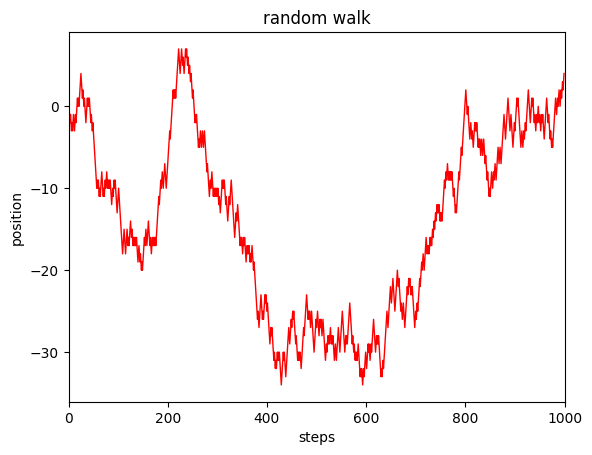

-34
7
413


In [34]:
import numpy as np
import matplotlib.pyplot as plt
import pylab
import random
nsteps = 1000  # 模拟步数
draws = np.random.randint(0,2,size=nsteps)  # 每步生成 0 或 1
steps = np.where(draws>0,1,-1)  # 0 映射为 +1,1 映射为 -1,得到每步方向
walk=steps.cumsum()  # 累加得到每一步之后的位置,即为随机游走轨迹
# print(walk)


x = np.arange(nsteps)  # 横坐标:步数 0~999
y = walk  # 纵坐标:位置序列
plt.plot(x,y,color = 'red', linewidth=1)  # 用红色细线绘制轨迹
plt.xlabel('steps')
plt.ylabel('position')
plt.title('random walk')
plt.xlim(0,1000)
pylab.show()

print(walk.min())  # 整个过程到达过的最低位置
print(walk.max())  # 到达过的最高位置
print((np.abs(walk) >= 30).argmax())  # 布尔数组的 argmax 返回首个 True 的位置,即首次离开正负 30 区间的步数